In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [12]:
df = pd.read_csv("benchmark_log.csv").set_index(["test_type", "n", "num_cpus"])
df["admm_time"] = df["solve"] - df["_get_grouped_objectives"] - df["get_subproblems"] - df["populate_vars_with_solution"]
df["admm_time_per_iter"] = df["admm_time"] / df["num_iterations"]
df["group_time"] = df["_get_grouped_objectives"]
df["misc_time"] = df["__init__"] + df["get_subproblems"] + df["populate_vars_with_solution"]
df = df.rename({"solve": "total_time"}, axis=1)
df

num_iterations  __init__  _get_grouped_objectives  \
test_type n    num_cpus                                                      
sum       100  1                      4    0.7919                   9.1884   
weighted  30   1                     31    0.1429                   8.0203   
log       10   1                      7    0.0432                   8.2551   
sum       100  2                      4    0.9513                   8.8755   
weighted  30   2                     28    0.3239                   8.6687   
...                                 ...       ...                      ...   
          300  16                     4    5.5414                  19.3091   
log       100  16                    10    1.0951                  37.8821   
sum       1000 32                     4   59.8369                 192.4471   
weighted  300  32                     4    5.4325                  19.6247   
log       100  32                    10    1.0490                  37.7489   

                         get_subproblems  populate_vars_with_solution  \
test_type n    num_cpus                                                 
sum       100  1                  1.2988                       1.3027   
weighted  30   1                  0.1957                       0.1301   
log       10   1                  0.0950                       0.0283   
sum       100  2                  1.3446                       0.8009   
weighted  30   2                  0.2599                       0.0965   
...                                  ...                          ...   
          300  16                13.0602                       5.1387   
log       100  16                 3.0275                       0.5691   
sum       1000 32               139.0287                      54.2472   
weighted  300  32                14.5313                       4.5152   
log       100  32                 4.7104                       0.6112   

                         total_time  admm_time  admm_time_per_iter  \
test_type n    num_cpus                                              
sum       100  1            40.1739    28.3840            7.096000   
weighted  30   1            34.1195    25.7734            0.831400   
log       10   1            14.5797     6.2013            0.885900   
sum       100  2            27.4958    16.4748            4.118700   
weighted  30   2            25.0177    15.9926            0.571164   
...                             ...        ...                 ...   
          300  16           68.1455    30.6375            7.659375   
log       100  16           79.7990    38.3203            3.832030   
sum       1000 32          563.9802   178.2572           44.564300   
weighted  300  32           62.4321    23.7609            5.940225   
log       100  32           72.9958    29.9253            2.992530   

                         group_time  misc_time  
test_type n    num_cpus                         
sum       100  1             9.1884     3.3934  
weighted  30   1             8.0203     0.4687  
log       10   1             8.2551     0.1665  
sum       100  2             8.8755     3.0968  
weighted  30   2             8.6687     0.6803  
...                             ...        ...  
          300  16           19.3091    23.7403  
log       100  16           37.8821     4.6917  
sum       1000 32          192.4471   253.1128  
weighted  300  32           19.6247    24.4790  
log       100  32           37.7489     6.3706  

[180 rows x 10 columns]

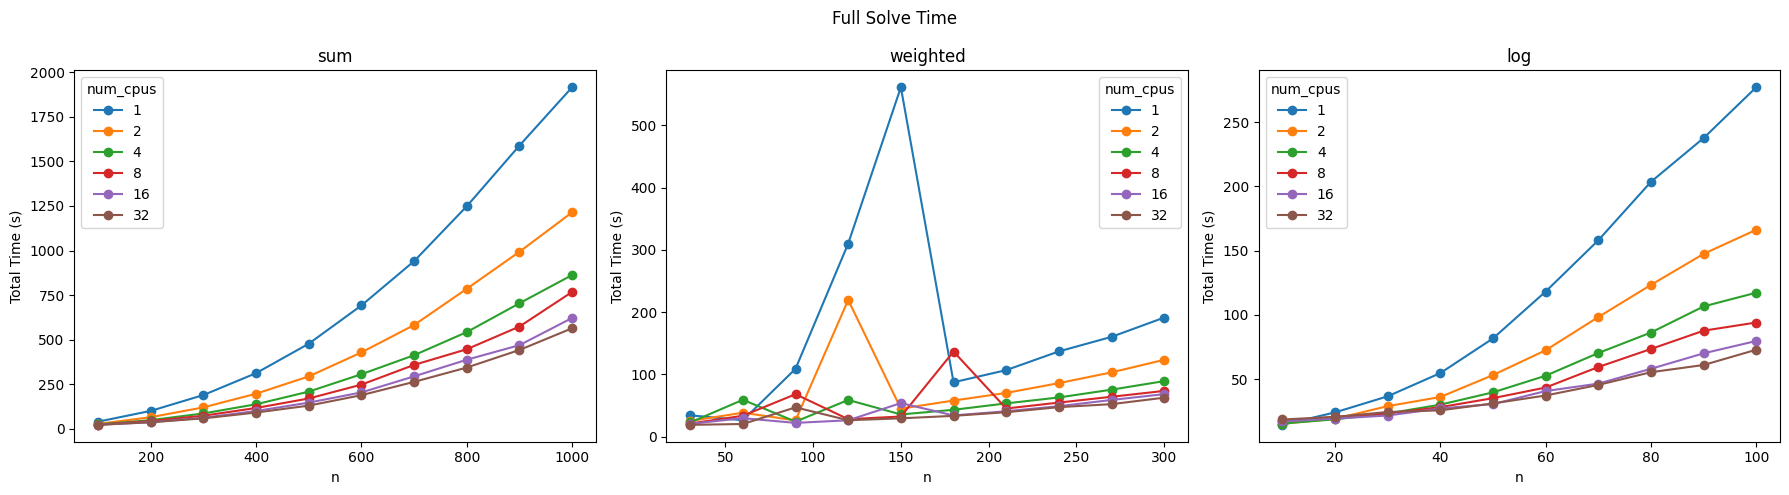

In [13]:
TEST_TYPES = ["sum", "weighted", "log"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["total_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Total Time (s)")
    ax.set_title(test_type)
fig.suptitle("Full Solve Time")
fig.tight_layout()
plt.show()

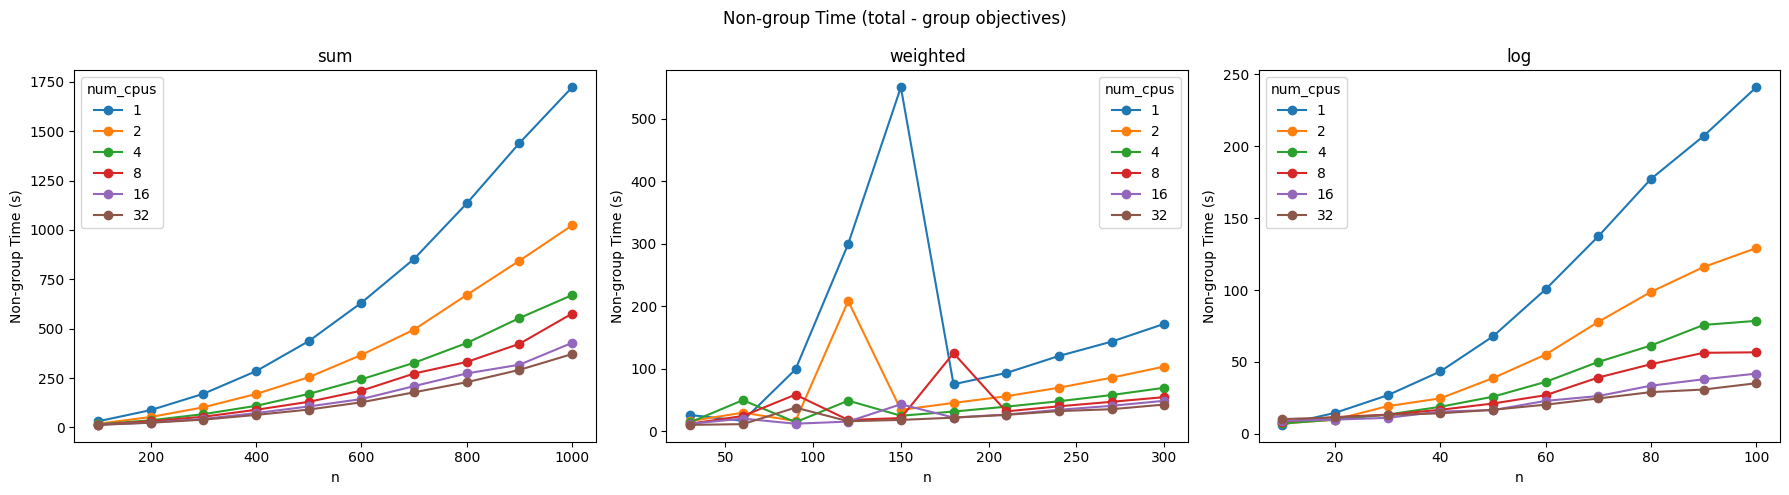

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["total_time"] - df_t["group_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Non-group Time (s)")
    ax.set_title(test_type)
fig.suptitle("Non-group Time (total - group objectives)")
fig.tight_layout()
plt.show()

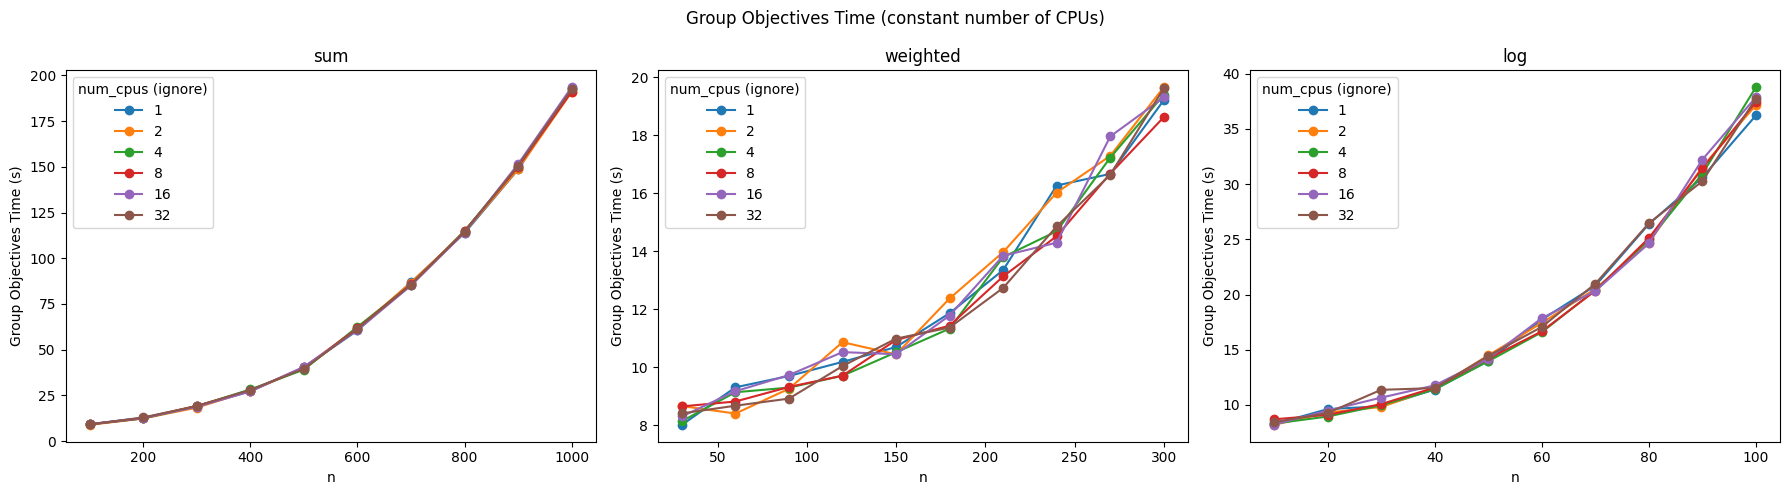

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["group_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["group_time"].columns, title="num_cpus (ignore)")
    ax.set_xlabel("n")
    ax.set_ylabel("Group Objectives Time (s)")
    ax.set_title(test_type)
fig.suptitle("Group Objectives Time (constant number of CPUs)")
fig.tight_layout()
plt.show()

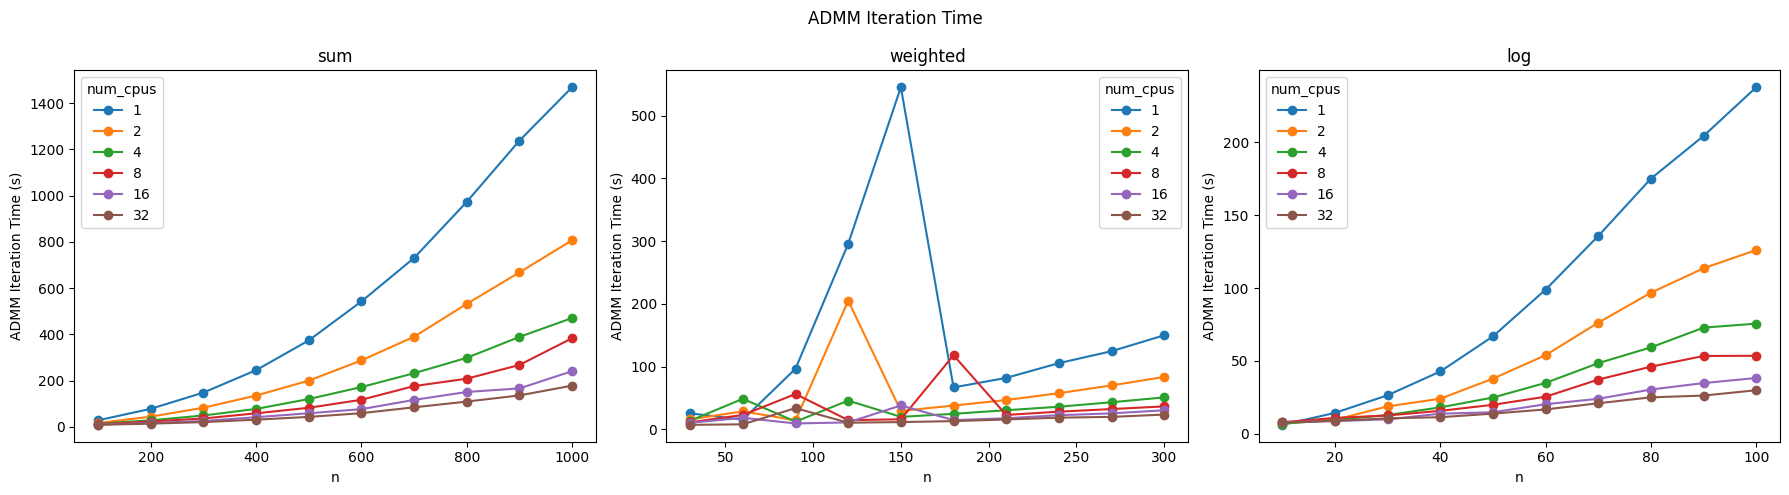

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time")
fig.tight_layout()
plt.show()

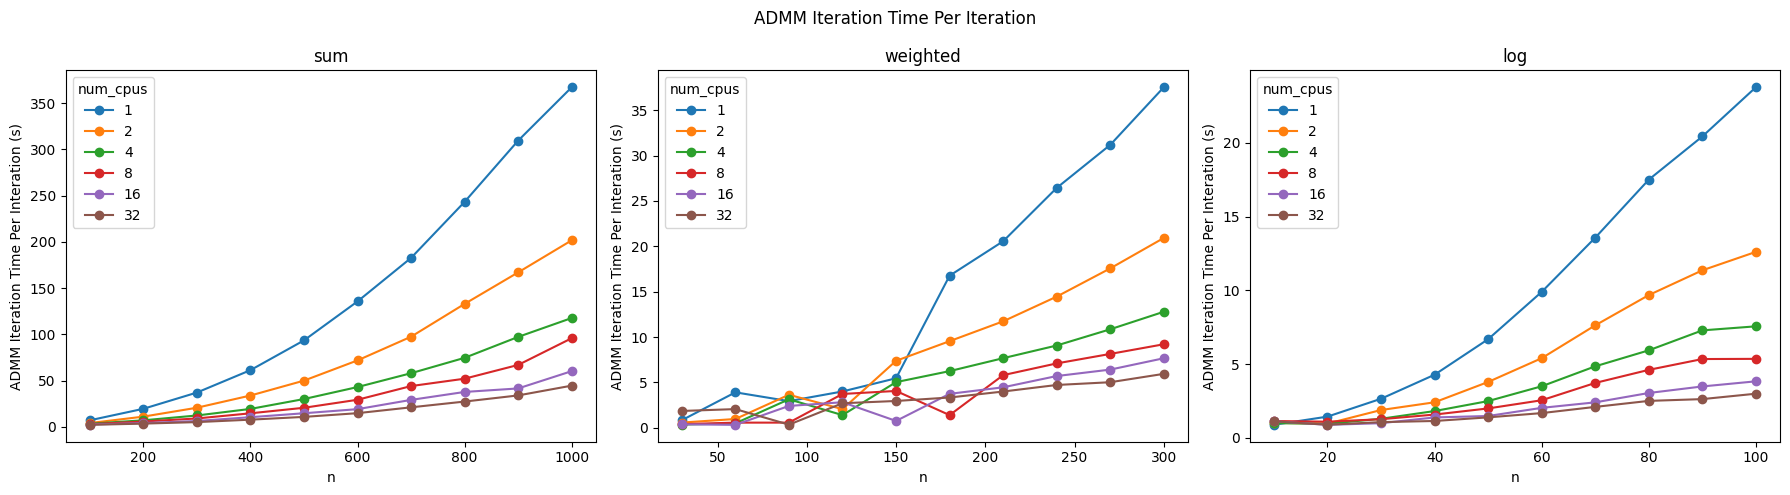

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time_per_iter"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time_per_iter"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time Per Interation (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time Per Iteration")
fig.tight_layout()
plt.show()

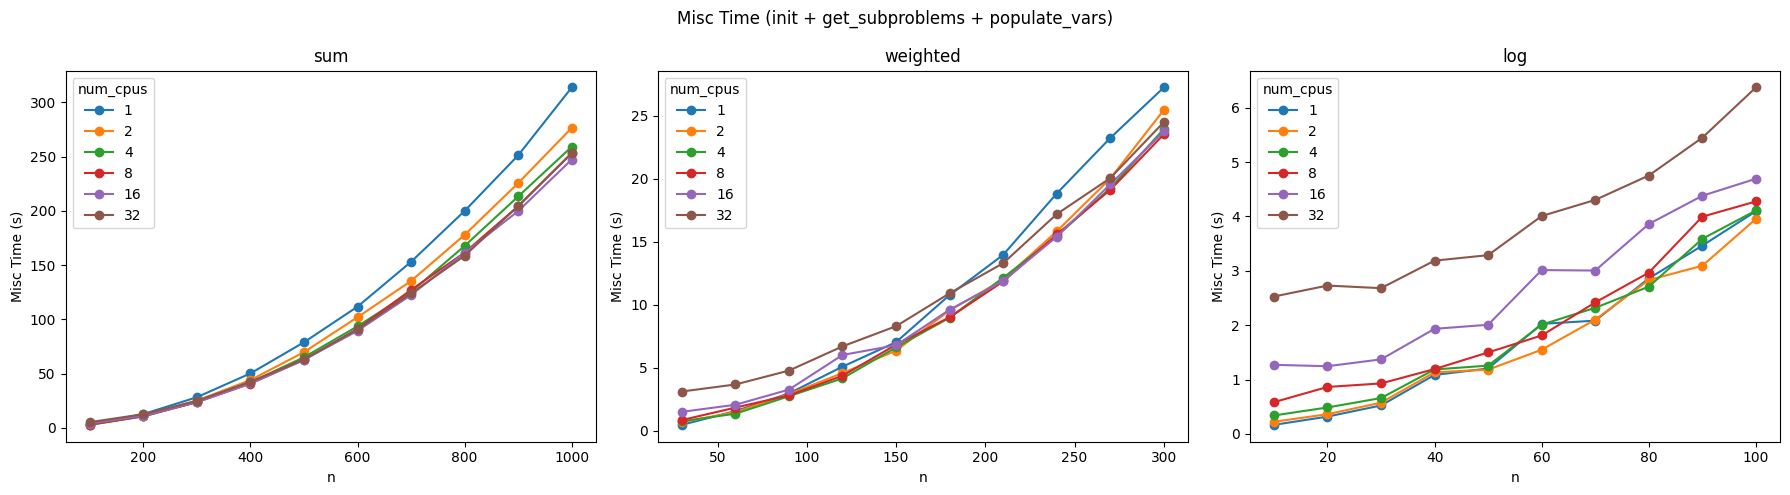

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["misc_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["misc_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Misc Time (s)")
    ax.set_title(test_type)
fig.suptitle("Misc Time (init + get_subproblems + populate_vars)")
fig.tight_layout()
plt.show()

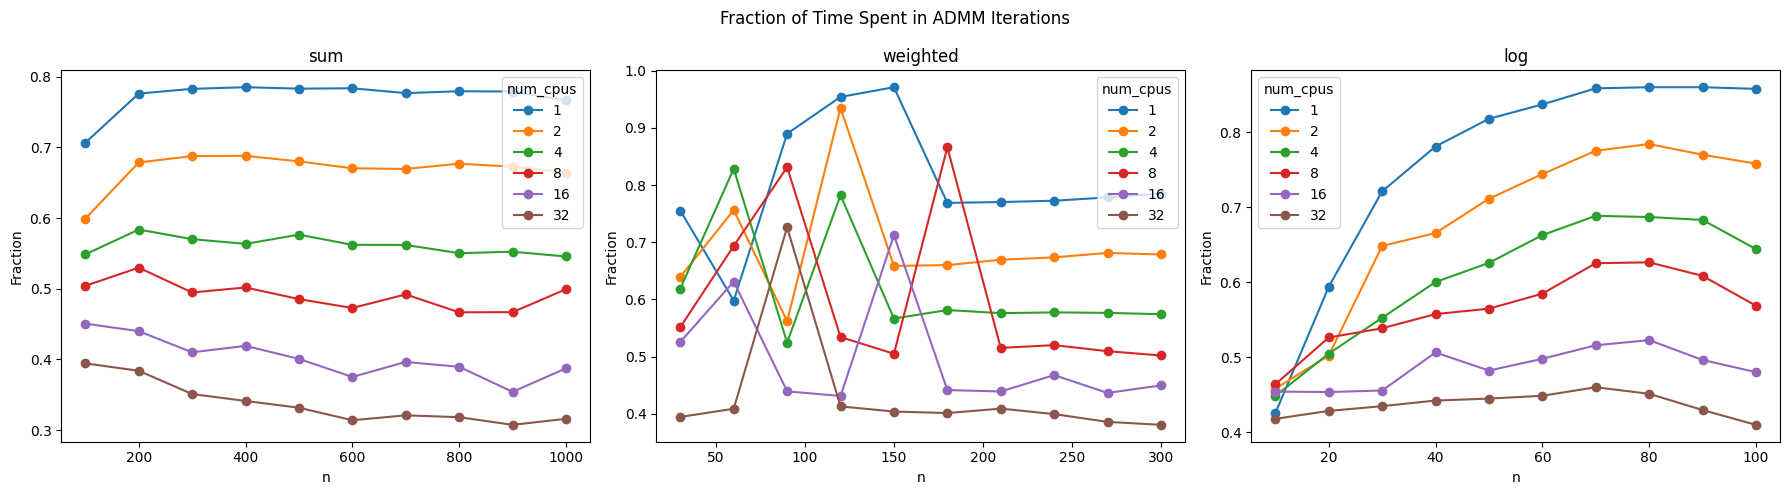

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["admm_time"] / df_t["total_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Fraction")
    ax.set_title(test_type)
fig.suptitle("Fraction of Time Spent in ADMM Iterations")
fig.tight_layout()
plt.show()

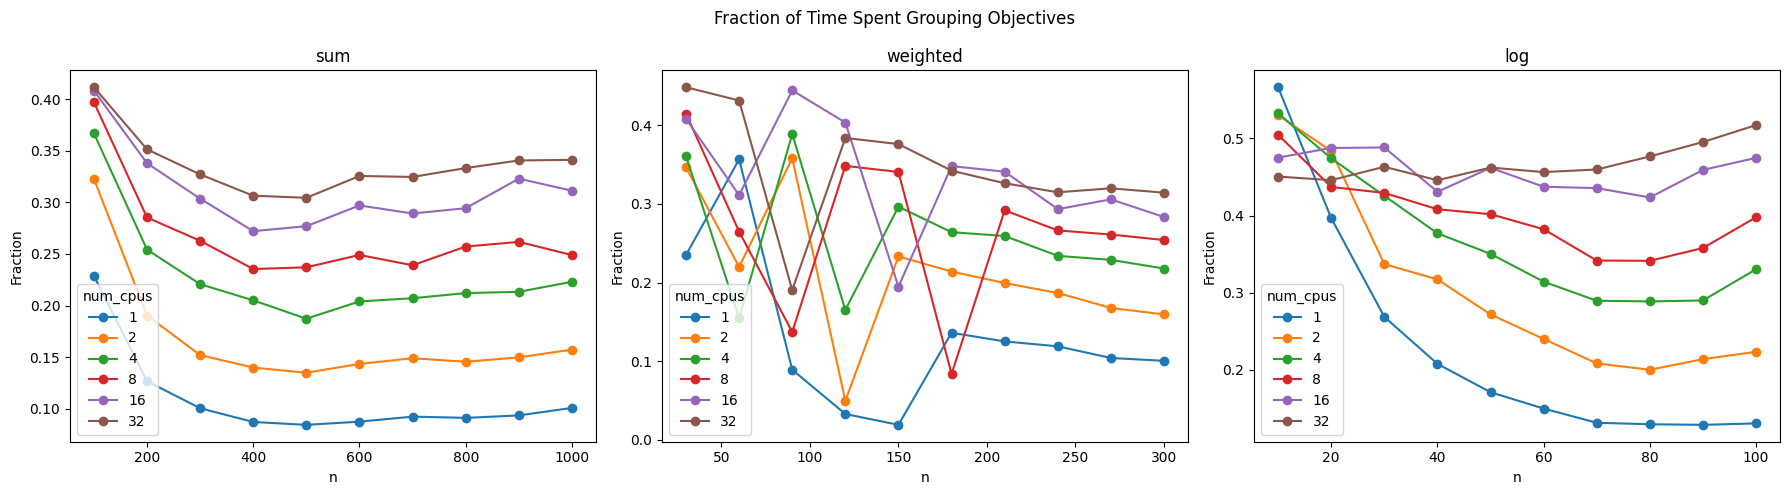

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["group_time"] / df_t["total_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["group_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Fraction")
    ax.set_title(test_type)
fig.suptitle("Fraction of Time Spent Grouping Objectives")
fig.tight_layout()
plt.show()